In [20]:
import pandas as pd
import matplotlib.pyplot as plt

Exploring data, columns, shape, and data types: 

In [ ]:
df =pd.read_csv("../data/raw/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [22]:
df.shape

(1338, 7)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [24]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


There are 1338 records. 
Avg. age is about 39 years, ages range from 18 to 64 years.
Avg. BMI is 30.66. Most people have around 1 child, number ranges from 0 to 5.

Avg. insurance charge is about $13270.
High std deviation and max. value of $63770 shows htat charge vary widely.
It means there are widespread outliers and the charges are spread out.

In [25]:
# check missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

there are no null values

In [ ]:
# exploring values in different categories
categories = ['sex','smoker','region']
for num in categories:
    print(df[num].value_counts())
    print()

sex
male      676
female    662
Name: count, dtype: int64

smoker
no     1064
yes     274
Name: count, dtype: int64

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64



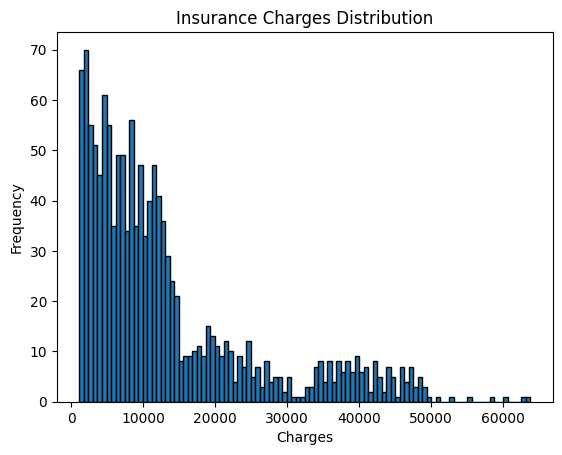

In [ ]:
# Insurance charge distribution plot

plt.hist(df['charges'],bins=100, edgecolor='black')
plt.title("Insurance Charges Distribution")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

It shows large number of people have low to medium charges. 
A few people have very high charges (outliers) 

Possible impacts on models we use: 

Linear Regression model: 
Since linear regression is linear and assumes normal distribution of data, our model might be impacted by the presence of extreme outliers. Better approach would be to use log transformation, which would make the model normal and improves performance.

Random forest model:
This is non-linear and tree based so it is better for random outliers.

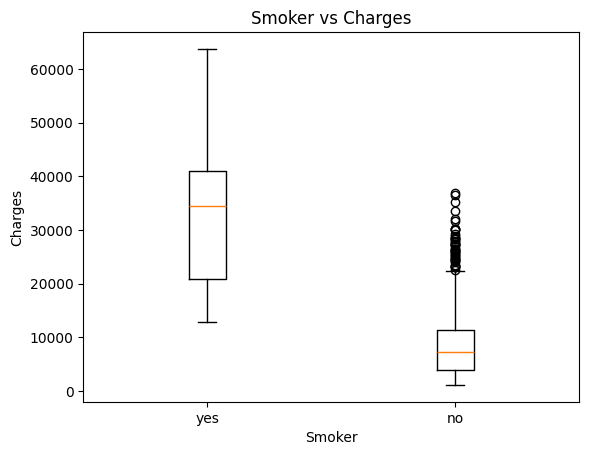

In [37]:
# smoker vs. charges

groups = [df[df['smoker'] == status]['charges'] for status in df['smoker'].unique()]
plt.boxplot(groups, tick_labels=df['smoker'].unique())
plt.title("Smoker vs Charges")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

Smokers have very high chartges with median of arpund 35k. Non- smokers have low charges. There is no overlap in distributions. 

Smoker is a strong predictor. 

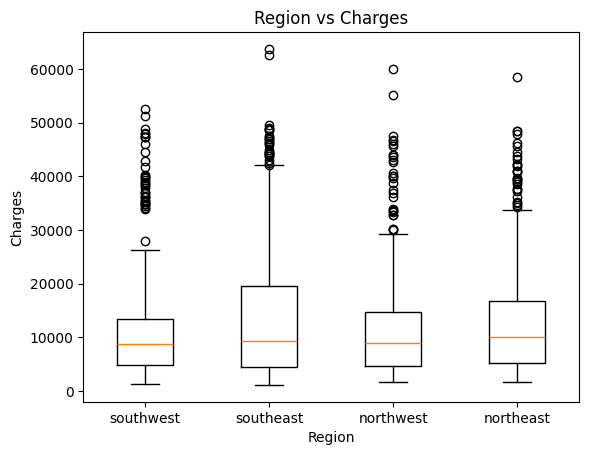

In [38]:
# Region vs Charges
groups = [df[df['region']==region]['charges'] for region in df['region'].unique()]
plt.boxplot(groups, tick_labels=df['region'].unique())
plt.title("Region vs Charges")
plt.xlabel("Region")
plt.ylabel("Charges")
plt.show()

All regions have similar medians. Data overlaps heavily. There are some outliers in each region. 

Region is a weak predictor.

In [ ]:
# Correlation analysis
# (converting categorical values to numerical values)

cols = df.copy()
cols['sex'] = cols['sex'].map({'male': 0,'female': 1})
cols['smoker'] = cols['smoker'].map({'no': 0,'yes': 1})
cols = pd.get_dummies(cols,columns=['region'],drop_first=True)

corr_matrix = cols.corr()


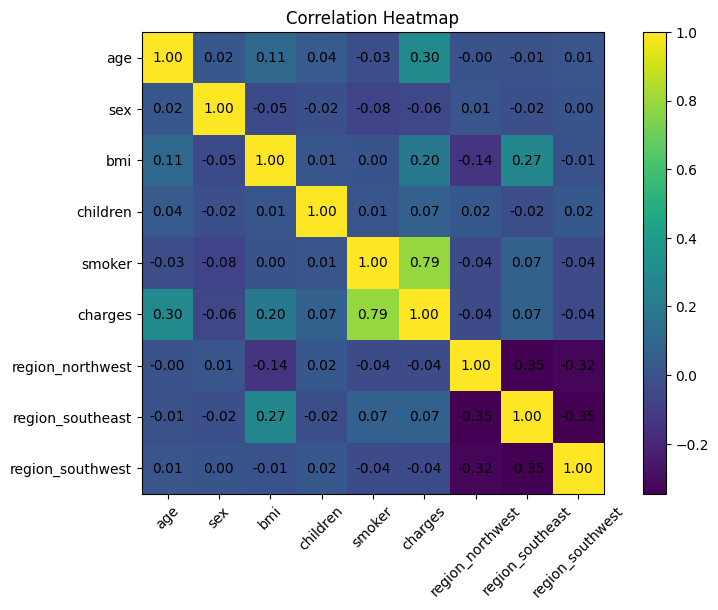

In [ ]:
plt.figure(figsize=(10,6))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap")

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j,i,f"{corr_matrix.iloc[i, j]:.2f}",ha='center',va='center')
plt.show()

Here too, we can see smoker has strong relationship (r=0.79) with charges. some other moderately important features are age and bmi. Region doesnt affe ct charges, looking at correlation.  

EDA findings: 
1. Dataset shows non-linear patterns and outliers.
2. Smoking has strong positive relationship with charges. 
3. All regions have similar distribution of charegs. 